## Mesh Resolution vs. Error
In this notebook, I fix the target rank (10, 25, 50), and increase the mesh resolution ($N$) to see how this affects the error. Question to be answered: Can we estimate a target rank-$k$ on a low-resolution mesh, and use it on high resolution meshes?

---

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, UnitSquareMesh, FunctionSpace

from utils.problem_setup import TestProblemsSetup
from utils.utils import progress_bar, disk_cache
from utils.metrics import error3
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

In [133]:
@disk_cache('../../results/mesh_resolution')
def experiment(k_list, N_range, pid, repeat=1):
    results = []

    n_steps, step = len(k_list) * len(N_range) * repeat, 1
    for N in N_range:
        n = round(np.sqrt(N))
        pb = TestProblemsSetup(n).get_single_problem(pid)

        rsvd = MatrixFreeRSVD(pb['V_h'])
        for k in k_list:
            for r in range(repeat):
                progress_bar(step, n_steps, end_text=f' [{N=:,}]')
                step += 1

                rsvd.solve(k=k, seed=None)
                w = rsvd.weights()
                x_hat = rsvd.tikhonov_solve(pb['y'], w, lam=1e-4)

                err = error3(pb['x'], x_hat)
                err['euclidean_rel'] = err['euclidean'] / np.linalg.norm(pb['x'])
                err['emd_rel'] = err['emd'] / N

                result = {'N': N, 'k': k, 'r': r}
                result.update(err)
                results.append(result)

    return pd.DataFrame(results)




k_list = [10, 25, 50]
N_range = np.linspace(4_000, 40_000, 101, dtype=int)

df = experiment(k_list, N_range, pid='I', repeat=5)

[##############################] 1515/1515 [N=40,000]


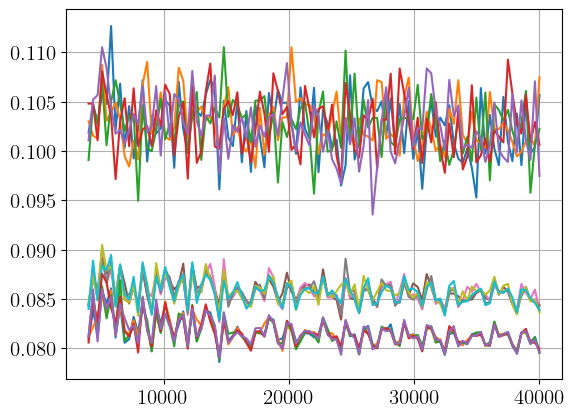

In [138]:
metric = 'emd_rel'

for k in k_list:
    for r in df.r.unique():
        dfr = df[(df.r == r) & (df.k == k)]
        plt.plot(dfr.N, dfr[metric])
    
#plt.ylim(0.7, 1.0)
plt.grid()

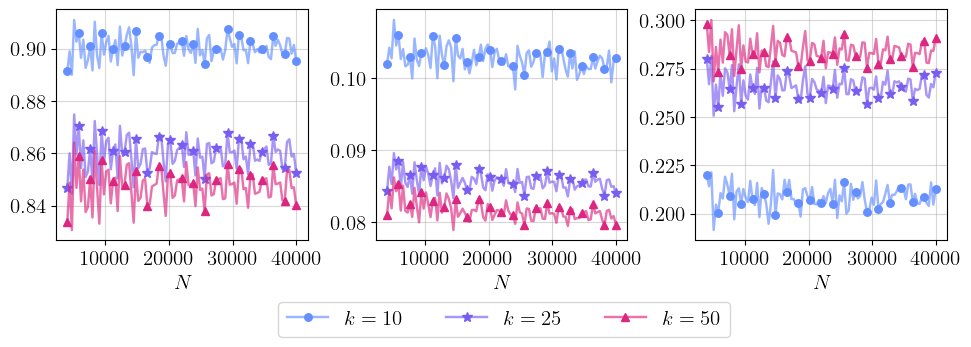

In [168]:
from utils.colors import C3, M, MS, LS
from matplotlib.lines import Line2D
from utils.plotting import save_plot

df2 = df.groupby(['N', 'k']).agg('mean').reset_index()

def plot_df2(df2, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3))

    s = 5
    metric = ['euclidean_rel', 'emd_rel', 'auc_iou']
    names = ['Euclidean', 'EMD', 'AUC-IoU']
    for i, ax in enumerate(axes.flat):
        for j, k in enumerate(k_list):
            dfk = df2[df2.k == k]

            ax.plot(dfk.N, dfk[metric[i]], c=C3[j], lw=1.75, alpha=0.65, ls='-')
            ax.plot(dfk.N[::s], dfk[metric[i]][::s], M[j], ms=MS[j] * 0.9, c=C3[j])

        ax.set_xlabel('$N$')
        ax.grid(True, alpha=.5)

    # Custom labels
    handles, labs = [], []
    for i, k in enumerate(k_list):
        legend_line = Line2D([0], [0], color=C3[i], linewidth=1.75, alpha=0.65)
        legend_marker = Line2D([0], [0], color=C3[i], marker=M[i], markersize=MS[i] * 0.9, linestyle='None')
        handles.append((legend_line, legend_marker))
        labs.append(f'$k={k}$')

    axes[1].legend(handles=handles, labels=labs, bbox_to_anchor=(1.45, -0.22), ncols=3)
    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.27)
    save_plot(fig_name)
    plt.show()


plot_df2(df2, fig_name='mesh_resolution_effect')